# Notebook 04 — Baseline Models

**Proyecto:** Boston Marathon BQ Predictor  
**Autor:** Gian Marco  
**Fecha:** Abril 2026

## Objetivos

1. Establecer un suelo de referencia con DummyClassifier (dos estrategias)
2. Entrenar un baseline lineal (LogisticRegression) con StandardScaler
3. Entrenar un baseline no-lineal simple (DecisionTree) con controles anti-overfitting
4. Comparar los tres modelos con validación cruzada (5-fold) dentro del train
5. Reportar F1 (clase positiva), PR-AUC y ROC-AUC
6. Identificar el ganador de los baselines para contrastarlo con modelos avanzados en el Notebook 05

## Regla fundamental

El `test_features.csv` NO se toca en este notebook. Toda comparación es vía CV sobre `train_features.csv`. El test se reserva para el Notebook 07.

## Métrica de decisión

**F1-score de la clase positiva (BQ=1).** Las otras dos (PR-AUC y ROC-AUC) se reportan pero no deciden el ranking.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup listo')

Setup listo


---
## 1. Cargar datos y separar X / y

In [4]:
train = pd.read_csv(PROCESSED_DATA_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

# El Year lo descartamos como feature (ver DECISIONS.md Decisión 3)
if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'Features: {X.columns.tolist()}')
print(f'\n% BQ en train: {y.mean()*100:.2f}%')
print(f'Desbalance 1:{(y==0).sum() / (y==1).sum():.2f}')

Shape X: (225356, 22)
Shape y: (225356,)
Features: ['Age', 'Is_Home_Country', 'Race_Category_enc', 'Race_te', 'Age_Squared', 'Gender_M', 'Country_AU', 'Country_BR', 'Country_CA', 'Country_DE', 'Country_ES', 'Country_FR', 'Country_GB', 'Country_IE', 'Country_IT', 'Country_JP', 'Country_MX', 'Country_NL', 'Country_Other', 'Country_PL', 'Country_TH', 'Country_US']

% BQ en train: 13.45%
Desbalance 1:6.43


---
## 2. Configuración de validación cruzada

Usamos `StratifiedKFold` con 5 folds. La estratificación asegura que cada fold mantiene la proporción 87/13 del target, evitando folds con muy pocos BQ.

Definimos un `scorers` dict con las 3 métricas para que `cross_validate` nos las devuelva todas en una pasada.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

print('CV configurado: StratifiedKFold con 5 folds')
print(f'Métricas a calcular: {list(scoring.keys())}')

CV configurado: StratifiedKFold con 5 folds
Métricas a calcular: ['f1_pos', 'precision_pos', 'recall_pos', 'pr_auc', 'roc_auc']


---
## 3. Función auxiliar para resumir resultados de CV

In [6]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper listo')

Helper listo


---
## 4. Dummy 1 — Most Frequent

Predice siempre la clase mayoritaria (no-BQ). Expondrá por qué accuracy NO es una métrica útil aquí.

In [7]:
dummy_mf = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
cv_out = cross_validate(dummy_mf, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'Dummy (most_frequent)')
results.append(summary)

print(f"F1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"\nInterpretación: F1=0 porque nunca predice BQ=1. Demuestra que accuracy miente.")

F1 (clase pos):  0.0000 ± 0.0000
Precision:       0.0000
Recall:          0.0000
PR-AUC:          0.1345
ROC-AUC:         0.5000

Interpretación: F1=0 porque nunca predice BQ=1. Demuestra que accuracy miente.


---
## 5. Dummy 2 — Stratified

Predice aleatoriamente respetando la proporción 87/13. Es el "azar informado por el desbalance".

In [8]:
dummy_strat = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
cv_out = cross_validate(dummy_strat, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'Dummy (stratified)')
results.append(summary)

print(f"F1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"\nInterpretación: F1≈{y.mean():.3f} (la proporción base). ROC-AUC≈0.5 porque es literalmente azar.")

F1 (clase pos):  0.1378 ± 0.0001
PR-AUC:          0.1350
ROC-AUC:         0.5020

Interpretación: F1≈0.135 (la proporción base). ROC-AUC≈0.5 porque es literalmente azar.


---
## 6. Logistic Regression con StandardScaler

Pipeline = StandardScaler + LogReg para evitar leakage del scaling en CV.

Configuración:
- `max_iter=1000` — asegurar convergencia
- Sin `class_weight='balanced'` aún — lo probaremos en el Notebook 06

In [9]:
logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

cv_out = cross_validate(logreg_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'LogisticRegression')
results.append(summary)

print(f"F1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

F1 (clase pos):  0.1666 ± 0.0062
Precision:       0.5488
Recall:          0.0982
PR-AUC:          0.3276
ROC-AUC:         0.7286
Tiempo fit medio: 0.53s


---
## 7. Decision Tree con controles anti-overfitting

- `max_depth=8`
- `min_samples_leaf=50`

In [10]:
dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
)

cv_out = cross_validate(dt, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'DecisionTree (depth=8, leaf=50)')
results.append(summary)

print(f"F1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

F1 (clase pos):  0.1506 ± 0.0144
Precision:       0.5693
Recall:          0.0870
PR-AUC:          0.3263
ROC-AUC:         0.7316
Tiempo fit medio: 0.30s


---
## 8. Tabla comparativa de los baselines

Consolidamos los resultados de los 4 modelos en una tabla única para facilitar la comparación y la slide de la presentación.

In [11]:
df_results = pd.DataFrame(results)

# Columnas de media con formato bonito
metric_cols = ['f1_pos_mean', 'precision_pos_mean', 'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean']
display_df = df_results[['model'] + metric_cols + ['fit_time_mean']].copy()

# Renombrar para la tabla
display_df.columns = ['Modelo', 'F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC', 'Fit time (s)']

# Formatear números
for col in ['F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['Fit time (s)'] = display_df['Fit time (s)'].apply(lambda x: f'{x:.2f}')

# Ordenar por F1 descendente
display_df = display_df.sort_values('F1 (pos)', ascending=False).reset_index(drop=True)

print('RANKING DE BASELINES (ordenados por F1 de clase positiva)')
print('=' * 90)
print(display_df.to_string(index=False))

RANKING DE BASELINES (ordenados por F1 de clase positiva)
                         Modelo F1 (pos) Precision Recall PR-AUC ROC-AUC Fit time (s)
             LogisticRegression   0.1666    0.5488 0.0982 0.3276  0.7286         0.53
DecisionTree (depth=8, leaf=50)   0.1506    0.5693 0.0870 0.3263  0.7316         0.30
             Dummy (stratified)   0.1378    0.1380 0.1376 0.1350  0.5020         0.04
          Dummy (most_frequent)   0.0000    0.0000 0.0000 0.1345  0.5000         0.07


---
## 9. Visualización comparativa

Un gráfico de barras agrupadas para ver de un vistazo el rendimiento relativo de los 4 modelos en las 3 métricas clave.

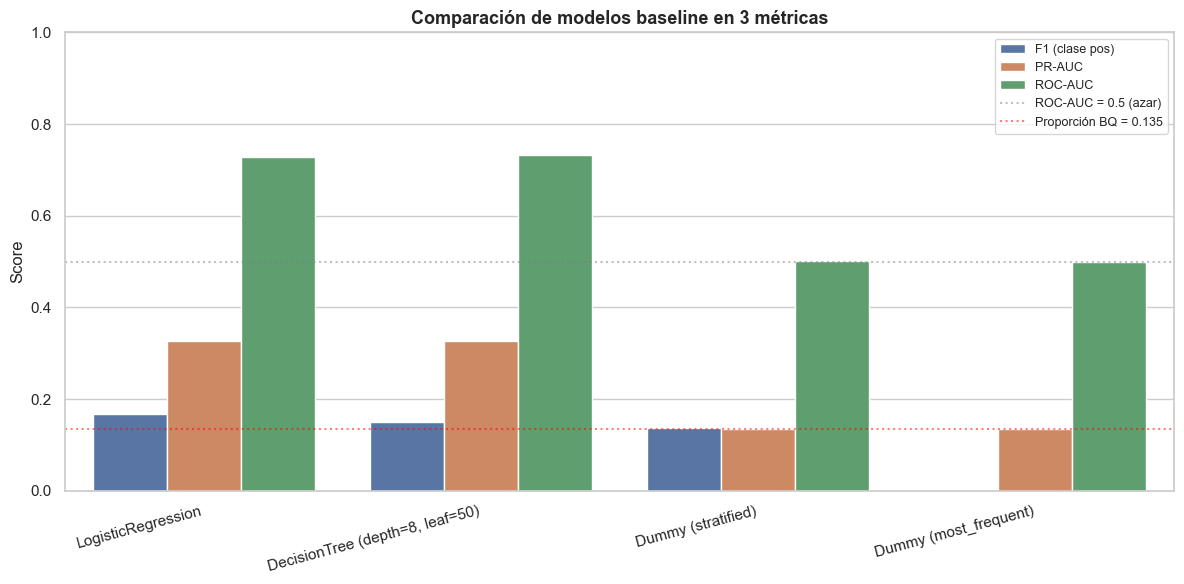

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Preparar datos en formato largo para seaborn
plot_df = df_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (clase pos)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

# Orden fijo para legibilidad
model_order = df_results.sort_values('f1_pos_mean', ascending=False)['model'].tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='model', y='score', hue='metric',
            order=model_order, palette='deep', ax=ax, edgecolor='white')

# Líneas de referencia
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (azar)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'Proporción BQ = {y.mean():.3f}')

ax.set_title('Comparación de modelos baseline en 3 métricas', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=15, ha='right')

plt.tight_layout()

# Guardar para la presentación
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / '08_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Guardar resultados consolidados

Guardamos la tabla de resultados como CSV para reutilizarla en el Notebook 05 (comparativa contra modelos avanzados) y en la presentación final.

In [13]:
df_results.to_csv(PROCESSED_DATA_DIR / 'baseline_results.csv', index=False)
print(f'Resultados guardados en: {PROCESSED_DATA_DIR / "baseline_results.csv"}')
print(f'\nGanador de los baselines (por F1): {df_results.sort_values("f1_pos_mean", ascending=False).iloc[0]["model"]}')

Resultados guardados en: ../data/processed/baseline_results.csv

Ganador de los baselines (por F1): LogisticRegression


---
## 11. Interpretación final y conclusiones del Notebook 04

### Ranking por F1 de clase positiva

1. **LogisticRegression** — F1 = 0.167 (ganador del baseline)
2. **DecisionTree (depth=8, leaf=50)** — F1 = 0.151
3. **Dummy (stratified)** — F1 = 0.138
4. **Dummy (most_frequent)** — F1 = 0.000

### Observaciones clave

**1. Los modelos reales apenas baten al azar informado.** Solo ~3 puntos de F1 sobre el Dummy stratified. Hay mucho margen de mejora.

**2. Accuracy es engañoso.** El Dummy most_frequent tendría 86.5% accuracy, mejor que cualquier otro modelo en esta métrica, sin haber aprendido nada. Justifica haber elegido F1 y PR-AUC como métricas principales.

**3. Gap gigante entre precision y recall.** Con threshold 0.5:
   - Cuando el modelo predice BQ, acierta el 55%
   - Pero solo detecta el ~9% de los BQ reales
   
   Es el síntoma clásico de desbalance + threshold conservador. Estrategias para atacarlo en los próximos notebooks:
   - `class_weight='balanced'` (Notebook 06)
   - SMOTE oversampling (Notebook 06)
   - Threshold tuning (Notebook 07)

**4. LogReg > DT en este baseline.** Contraintuitivo pero explicable: las restricciones anti-overfitting del DT (max_depth=8) también le impiden capturar interacciones finas. Además, `Age_Squared` permite a LogReg capturar parte de la no-linealidad. Los modelos no-lineales ganarán de verdad cuando levantemos restricciones en el Notebook 05 (Random Forest, XGBoost).

**5. ROC-AUC ~0.73 en ambos modelos reales.** Es un indicador más optimista que F1, pero menos informativo con clases desbalanceadas. Reportaremos ambos en la presentación final.